# Только трансформация координат (увеличение датасета)
(дисбалланс классов остался)

In [ ]:
import os
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn import tree
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

zip_file_name = '/content/drive/MyDrive/Европейский университет/Выпускной проект/dataset.zip'

Mounted at /content/drive


In [ ]:
import zipfile

zip_file_name = '/content/drive/MyDrive/Европейский университет/Выпускной проект/dataset.zip'

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall()

In [ ]:
labels_path = '/content/dataset┬áΓÇö ╨║╨╛╨┐╨╕╤Å/legs_positions_labels'
pics_path = '/content/dataset┬áΓÇö ╨║╨╛╨┐╨╕╤Å/legs_positions_pictures'

In [ ]:
class SkeletonDataset(Dataset):
    def __init__(self, images_root, coords_root, transform=None, point_transforms=None):
        self.images_root = images_root # пути к изображениям
        self.coords_root = coords_root # пути к координатам
        self.transform = transform # хранит переданные трансформации
        self.point_transforms = point_transforms # хранит переданные трансформации
        self.data = [] # сюда будут записаны пути к изображениям, файлы координат и метки классов
        self.class_to_idx = {} # словарь, сопоставляющий имя класса с индексом

        # Собираем все классы в словарь self.class_to_idx
        for class_name in sorted(os.listdir(images_root)):
            class_path = os.path.join(images_root, class_name)
            if os.path.isdir(class_path): # если элемент — папка,
                self.class_to_idx[class_name] = len(self.class_to_idx) # добавляем имя папки == имя класса в self.class_to_idx с индексом
        # Таким образом, каждому классу присваивается уникальный индекс (0, 1, 2 и т. д.).

        # Рекурсивно обходим папки с изображениями
        for root, _, files in os.walk(images_root):
            for file in files:
                if file.endswith(('.jpeg', '.png')):
                    # Получаем относительный путь к изображению
                    rel_path = os.path.relpath(os.path.join(root, file), images_root)
                    # Получаем путь к файлу с координатами
                    coord_path = os.path.join(coords_root, os.path.splitext(rel_path)[0] + '.txt')
                    # Проверяем, что соответствующий файл с координатами существует
                    if os.path.exists(coord_path):
                        image_path = os.path.join(images_root, rel_path)
                        # Извлекаем метку класса из имени подпапки
                        class_name = rel_path.split(os.sep)[0]
                        label = self.class_to_idx[class_name]
                        self.data.append((image_path, coord_path, label))

    def __len__(self):
        return len(self.data)

    # Загрузка элементов
    def __getitem__(self, idx):
        image_path, coords_path, label = self.data[idx] # получаем пути к изображениям и координатам
        image = Image.open(image_path).convert('RGB') # загружаем изображение и конвертируем сразу в RGB

        # Применяем трансформации к картинкам, если self.transform = True
        if self.transform:
            image = self.transform(image)

        # Загружаем координаты в виде масива numpy
        with open(coords_path, 'r') as f:
            coords = np.loadtxt(f)

        # ширина и высота скелета (разница между максимальным и минимальным значением по осям X и Y)
        width = coords[0,:].max() - coords[0,:].min()
        height = coords[1,:].max() - coords[1,:].min()

        # средние значения координат (центр скелета)
        cx = coords[0,:].mean()
        cy = coords[1,:].mean()

        # ОЛЕГ: Стоит нормализировать исходя из размеров самого скелетона
        coords[:, 0] = (coords[:, 0] - cx) / width  # нормализация широты
        coords[:, 1] = (coords[:, 1] - cy) / height  # нормализация высоты

        # Обрезаем значения в пределах [0, 1]
        coords = np.clip(coords, 0, 1)

        # Преобразуем координаты скелетона в тензор
        coords = torch.tensor(coords, dtype=torch.float32)

        # Если переданы специальные трансформации для координат (point_transforms), применяем их (при transformations = True)
        if self.point_transforms is not None:
            coords = self.point_transforms(coords)

        label = torch.tensor(label, dtype=torch.long) # превращаем метку класса в тензор

        return image, coords, label # получаем тензоры

In [ ]:
# transforms.Compose([...]) объединяет несколько преобразований в один пайплайн
transform = transforms.Compose([
    transforms.Resize((256, 256)), # изменяет изображения в меньший формат
    transforms.ToTensor(), # конвертирует изображение из формата PIL или NumPy в тензор PyTorch с диапазоном значений [0, 1] и порядком каналов (C, H, W)
])

In [ ]:
dataset = SkeletonDataset(images_root=pics_path,
                          coords_root=labels_path,
                          transform=transform) # передаем трансформацию для изображений

In [ ]:
dataloader = torch.utils.data.DataLoader(dataset,
                                         batch_size=32,
                                         shuffle=True) # перемешиваем

In [ ]:
# Итерация по dataloader возвращает images, coords и labels для одного батча
for images, coords, labels in dataloader:
    print("Размер изображений:", images.shape)  # размер тензора (batch_size, число цветовых каналов (RGB), 256, 256). последнее - размер изображения
    print("Размер координат:", coords.shape)    # (batch_size, num_nodes, 2). num_nodes — количество ключевых точек скелета, 2 - координаты x,y
    print("Размер меток:", labels.shape)         # (batch_size,) - размер меток классов, 32 (по одной метке на изображение)
    print("Пример меток:", labels[:5])           # Вывод первых 5 меток
    break

Размер изображений: torch.Size([32, 3, 256, 256])
Размер координат: torch.Size([32, 17, 3])
Размер меток: torch.Size([32])
Пример меток: tensor([24,  0, 24,  7, 13])


In [ ]:
# класс PointCoordsRandomTransform выполняет случайные трансформации координат точек (аугментацию)
class PointCoordsRandomTransform:
    def __init__(self, p_rot=0.5, # вероятность применения поворота
                 rot_range_deg=(-10, 10), # диапазон углов поворота в градусах
                 p_shift=0.5, # вероятность применения сдвига
                 shift=20, # максимальное значение сдвига по x и y
                 p_scale_x=0.5, # вероятность масштабирования по x
                 scale_x=(0.8, 1.2), # диапазон коэффициентов масштабирования по x
                 p_scale_y=0.5, # вероятность масштабирования по y
                 scale_y=(0.8, 1.2)): # диапазон коэффициентов масштабирования по y

        # сохраняем параметры
        self.p_rot = p_rot
        self.rot_range_deg = rot_range_deg
        self.p_shift = p_shift
        self.shift = shift
        self.p_scale_x = p_scale_x
        self.scale_x = scale_x
        self.p_scale_y = p_scale_y
        self.scale_y = scale_y

    # применение трансформации
    def __call__(self, coords):
        coords = coords.clone()  # Создаем копию тензора, чтобы избежать изменения оригинального тензора

        # Разделяем x, y и conf
        xy = coords[:, :2]  # только координаты x, y
        conf = coords[:, -1:]  # только уверенность модели

        # С вероятностью p_rot выполняем поворот
        if np.random.rand() < self.p_rot:
            angle = np.random.uniform(*self.rot_range_deg) # выбираем случайный угол поворота в заданном диапазоне (rot_range_deg)
            angle = np.deg2rad(angle) # переводим угол из градусов в радианы
            # Создаем матрицу поворота
            rot_mat = torch.tensor([[np.cos(angle), -np.sin(angle)],
                                    [np.sin(angle),  np.cos(angle)]], dtype=torch.float32)
            xy = xy @ rot_mat.T  # применяем поворот

        # С вероятностью p_shift выполняем случайный сдвиг
        if np.random.rand() < self.p_shift:
            # генерируем случайное смещение в диапазоне [-shift, shift] для x и y
            shift_val = torch.tensor(np.random.uniform(-self.shift, self.shift, size=(2,)), dtype=torch.float32)
            xy += shift_val # прибавляем shift_val к координатам точек

        # С вероятностью p_scale_x случайно изменяем масштаб по x (умножаем на случайное число из scale_x)
        if np.random.rand() < self.p_scale_x:
            xy[:, 0] *= np.random.uniform(*self.scale_x)

        # Аналогично масштабируем y с вероятностью p_scale_y
        if np.random.rand() < self.p_scale_y:
            xy[:, 1] *= np.random.uniform(*self.scale_y)

        transformed_coords = torch.cat([xy, conf], dim=1)  # склеиваем обратно x, y и conf

        return transformed_coords

In [ ]:
transform = PointCoordsRandomTransform()

# собираем данные в numpy массивы
X, y = [], []
for epoch in range(10): # увеличиваем датасет в 10 раз == 10 эпох
    for _, coords, label in dataset: # пропускаем изображение и смотрим только координаты и метки
        # оригинальные координаты
        X.append(coords.view(-1).numpy()) # coords.view(-1) превращает координаты в одномерный тензор
        y.append(label.item()) # превращает тензор-метку в обычное число

        # преображение координат
        transformed_coords = transform(coords)
        X.append(transformed_coords.view(-1).numpy())
        y.append(label.item())

# Превращаем списки X и y в массивы numpy для удобства работы
X = np.array(X)
y = np.array(y)

In [ ]:
print(len(X))
print(X.shape)
print(len(y))
print(y.shape)

39100
(39100, 51)
39100
(39100,)


In [ ]:
# Разделяем датасет на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, # 20% данных отправляем в тестовую выборку
                                                    random_state=42) # фиксируем случайное разбиение для воспроизводимости

print("Размеры данных:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Размеры данных:
X_train: (31280, 51)
X_test: (7820, 51)
y_train: (31280,)
y_test: (7820,)


### Пробуем обучить DecisionTreeClassifier

In [ ]:
# копируем датасеты для обучения модели
X_train_DecTree, X_test_DecTree, y_train_DecTree, y_test_DecTree = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [ ]:
# Инициализация и обучение модели
clf_DecTree = DecisionTreeClassifier(random_state=42) # random_state=42 фиксирует случайность (чтобы результаты были одинаковыми при каждом запуске)
clf_DecTree.fit(X_train_DecTree, y_train_DecTree) # обучаем модель на тренировочных данных

DecisionTreeClassifier(random_state=42)

In [ ]:
# Предсказание на тестовой выборке
y_pred_DecTree = clf_DecTree.predict(X_test_DecTree) # результаты сохраняем в y_pred_DecTree

In [ ]:
# Оценка точности
accuracy_DecTree = accuracy_score(y_test_DecTree, y_pred_DecTree) # доля правильно предсказанных примеров
print(f"Точность на тестовой выборке: {accuracy_DecTree:.2f}")

Точность на тестовой выборке: 0.89


In [ ]:
# Подробный отчет о классификации
print("Отчет о классификации:")
print(classification_report(y_test_DecTree, y_pred_DecTree))

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1063
           1       0.87      0.84      0.86        82
           2       0.82      0.78      0.80        74
           3       0.88      0.88      0.88        43
           4       0.83      0.75      0.79        72
           5       0.82      0.86      0.84       136
           6       0.89      0.93      0.91        89
           7       0.90      0.90      0.90       955
           8       0.70      0.88      0.78         8
           9       0.83      0.88      0.85       105
          10       0.88      0.91      0.89       416
          11       0.89      0.87      0.88       238
          12       0.67      0.80      0.73         5
          13       0.83      0.87      0.85       252
          14       0.80      0.85      0.82       262
          15       0.76      0.79      0.78        24
          16       0.92      0.89      0.91       999
    

In [ ]:
# Матрица ошибок
conf_matrix_DecTree = confusion_matrix(y_test_DecTree, y_pred_DecTree)
print("Матрица ошибок:")
print(conf_matrix_DecTree)

Матрица ошибок:
[[932   1   3   0   2   4   0  25   2   4   2   3   0  13  12   1  17   4
    5   9   1   0   0   1  10   4   8   0   0]
 [  3  69   0   0   0   0   0   5   0   0   1   0   0   0   3   0   1   0
    0   0   0   0   0   0   0   0   0   0   0]
 [  5   0  58   0   1   3   1   0   0   0   1   1   0   0   0   0   0   0
    2   0   0   0   0   0   1   0   1   0   0]
 [  1   0   0  38   0   1   0   0   0   0   0   0   0   0   0   0   0   1
    0   0   0   0   0   0   0   2   0   0   0]
 [  0   1   1   0  54   1   0   3   0   0   4   1   0   1   0   0   1   0
    3   0   0   1   0   0   0   1   0   0   0]
 [  1   0   1   0   0 117   1   2   0   0   2   1   0   1   1   0   1   1
    4   1   0   0   0   0   2   0   0   0   0]
 [  1   0   0   0   0   0  83   2   0   0   1   0   0   0   0   0   0   0
    0   0   1   0   0   1   0   0   0   0   0]
 [ 18   2   3   1   1   5   1 860   0   0   8   4   0   7   6   2  10   0
    6   4   4   1   0   4   4   3   1   0   0]
 [  0   0   0   

In [ ]:
# Точность модели на тестовых данных
accuracy_DecTree_test = accuracy_score(y_test_DecTree, y_pred_DecTree)
print(f"Точность на тестовой выборке: {accuracy_DecTree_test:.2f}")

Точность на тестовой выборке: 0.89


In [ ]:
# Подробный отчет о классификации
print("Отчет о классификации:")
print(classification_report(y_test_DecTree, y_pred_DecTree))

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1063
           1       0.87      0.84      0.86        82
           2       0.82      0.78      0.80        74
           3       0.88      0.88      0.88        43
           4       0.83      0.75      0.79        72
           5       0.82      0.86      0.84       136
           6       0.89      0.93      0.91        89
           7       0.90      0.90      0.90       955
           8       0.70      0.88      0.78         8
           9       0.83      0.88      0.85       105
          10       0.88      0.91      0.89       416
          11       0.89      0.87      0.88       238
          12       0.67      0.80      0.73         5
          13       0.83      0.87      0.85       252
          14       0.80      0.85      0.82       262
          15       0.76      0.79      0.78        24
          16       0.92      0.89      0.91       999
    

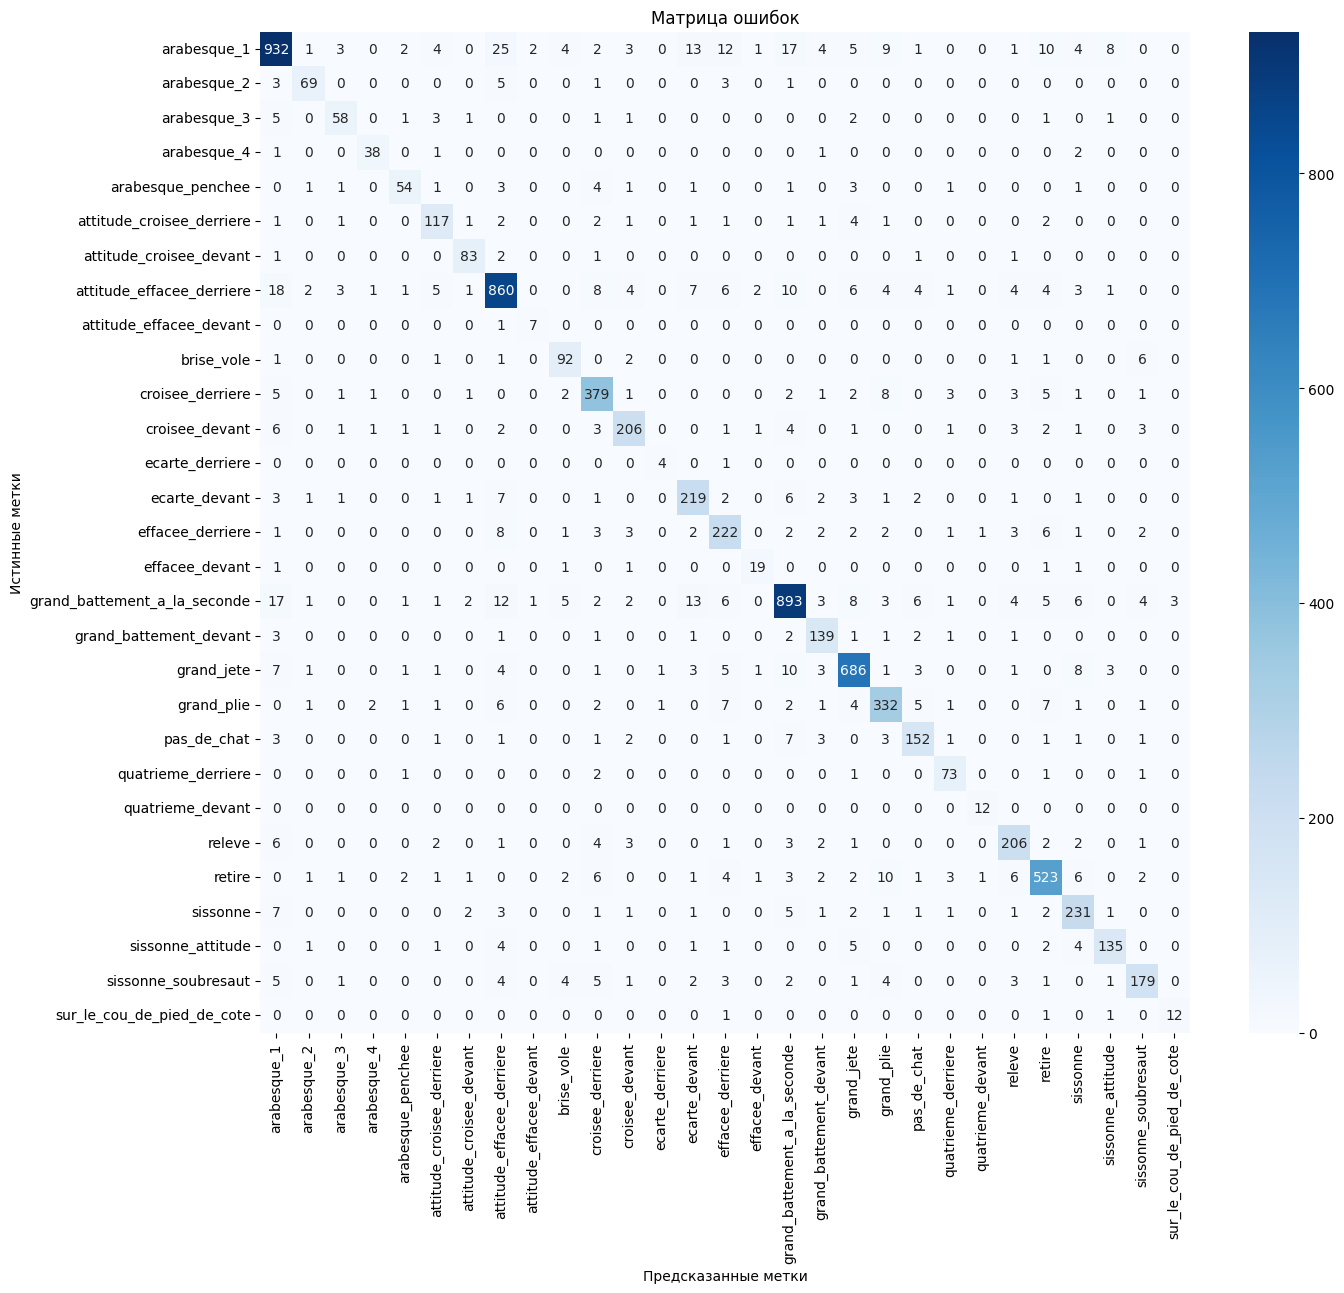

In [ ]:
from sklearn.metrics import confusion_matrix

# Матрица ошибок
conf_matrix_DecTree = confusion_matrix(y_test_DecTree, y_pred_DecTree)

# Визуализация матрицы ошибок
plt.figure(figsize=(15, 13))
sns.heatmap(conf_matrix_DecTree, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.class_to_idx.keys(), yticklabels=dataset.class_to_idx.keys())
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок')
plt.show()

In [ ]:
clf_DecTree.fit(X_train_DecTree, y_train_DecTree)

DecisionTreeClassifier(random_state=42)

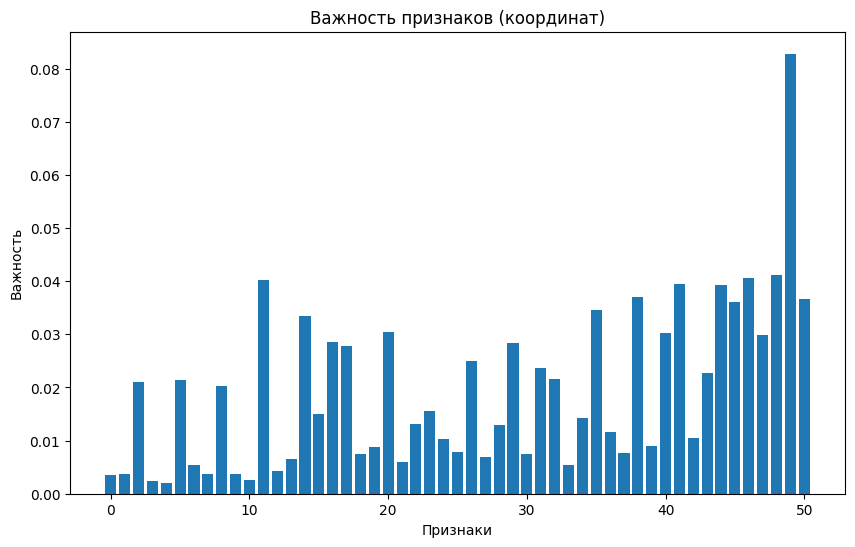

In [ ]:
# Визуализация важности признаков
feature_importance_DecTree = clf_DecTree.feature_importances_

# ОТКУДА ЭТИ ПРИЗНАКИ? КАК ПОНЯТЬ, ЧТО МОДЕЛЬ ОЦЕНИВАЕТ?

# Отображаем важность признаков
plt.figure(figsize=(10, 6))
plt.bar(range(X.shape[1]), feature_importance_DecTree)
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.title('Важность признаков (координат)')
plt.show()

In [ ]:
# import joblib

# # Сохраняем модель в файл
# model_filename = 'skeleton_classifier.pkl'
# joblib.dump(clf, model_filename)

# print(f"Модель сохранена в файле: {model_filename}")

Когда нужно использовать модель для предсказаний на новых данных:

In [ ]:
# # Загружаем модель из файла
# loaded_model = joblib.load(model_filename)

# # Проверка работы загруженной модели
# y_pred = loaded_model.predict(X_test)
# print("Точность загруженной модели:", accuracy_score(y_test, y_pred))

Визуализация дерева решений:

Деревья решений легко интерпретировать, поэтому полезно их визуализировать.

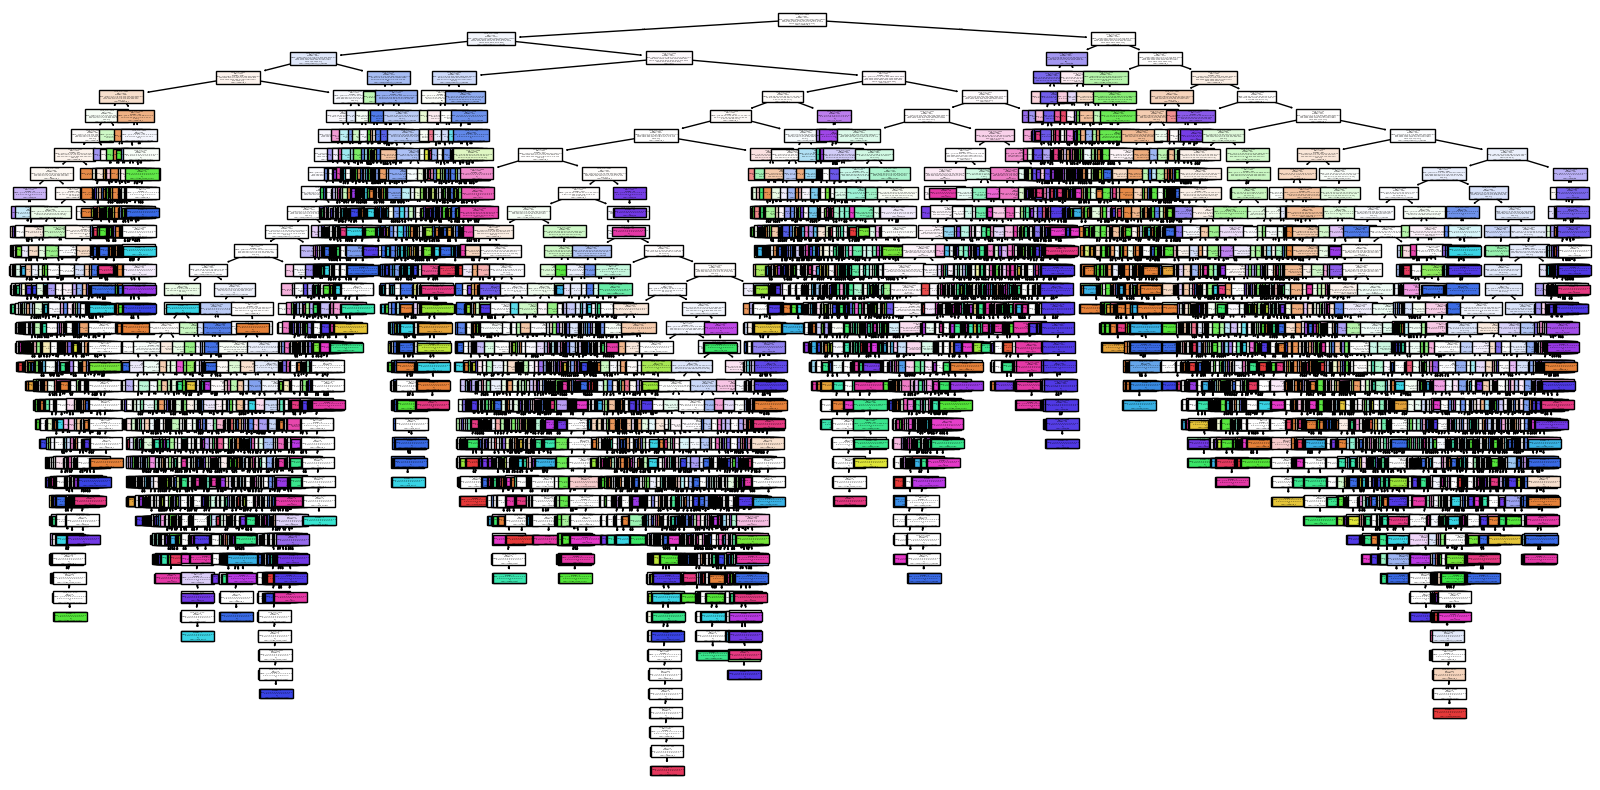

In [ ]:
# Визуализация дерева решений
plt.figure(figsize=(20, 10))
tree.plot_tree(clf_DecTree,
               feature_names=[f"coord_{i}" for i in range(X.shape[1])],
               class_names=[str(c) for c in dataset.class_to_idx.keys()],
               filled=True)
plt.show()

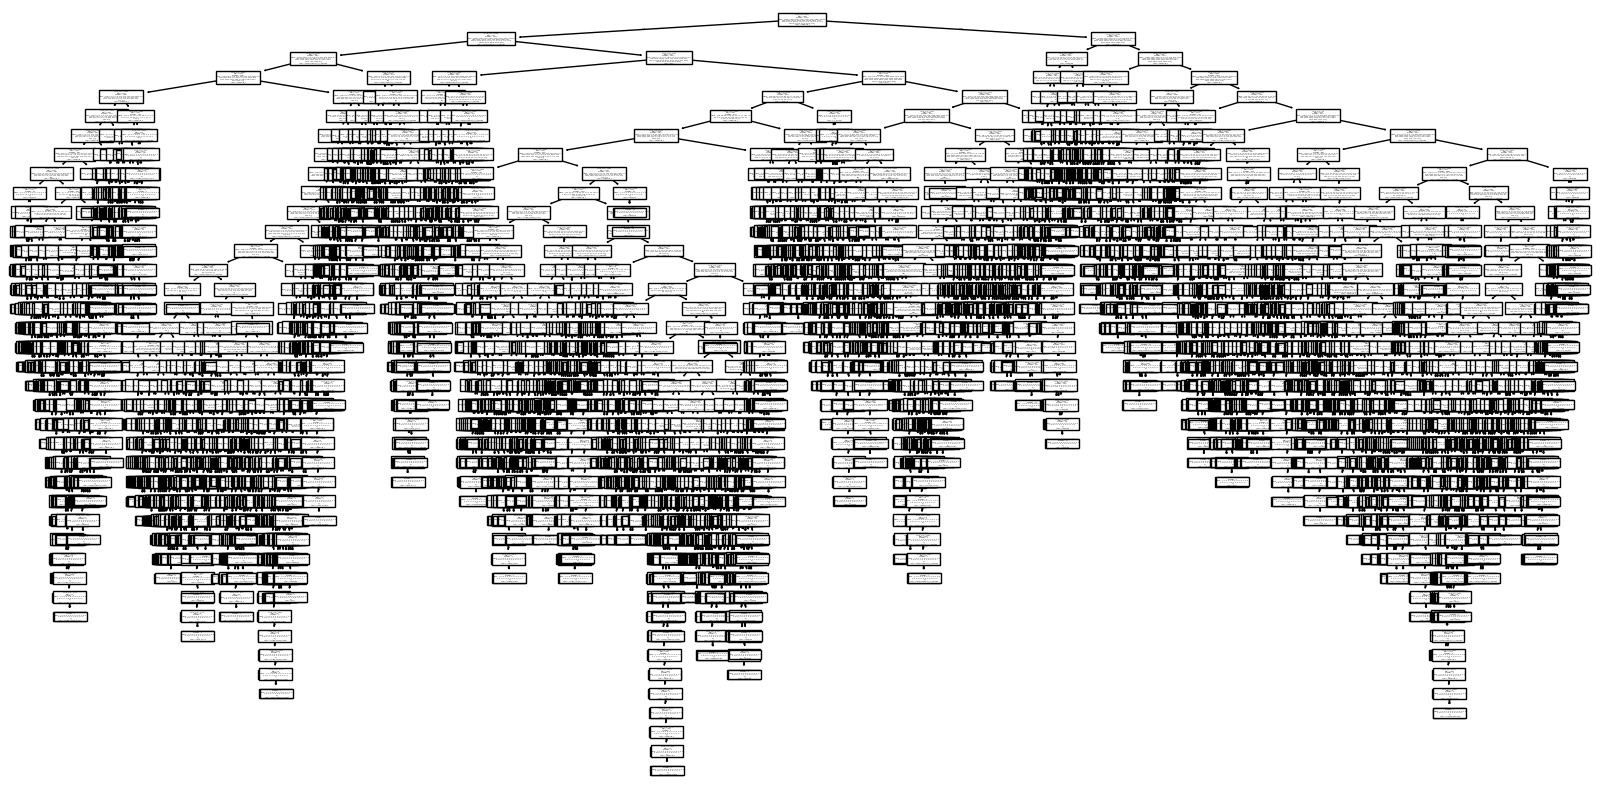

In [ ]:
# Визуализация дерева решений
plt.figure(figsize=(20, 10))
tree.plot_tree(clf_DecTree,
               feature_names=[f"coord_{i}" for i in range(X.shape[1])],
               class_names=[str(c) for c in dataset.class_to_idx.keys()],
               filled=False)
plt.show()

### Пробуем обучить SVC

In [ ]:
# копируем датасеты для обучения модели
X_train_SVC, X_test_SVC, y_train_SVC, y_test_SVC = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [ ]:
from sklearn.svm import SVC

# Инициализация и обучение модели
clf_SVC = SVC(kernel='rbf', random_state=42)
clf_SVC.fit(X_train_SVC, y_train_SVC)

SVC(random_state=42)

In [ ]:
# Предсказание на тестовой выборке
y_pred_SVC = clf_SVC.predict(X_test_SVC)

In [ ]:
# Оценка точности
accuracy_SVC = accuracy_score(y_test_SVC, y_pred_SVC)
print(f"Точность на тестовой выборке: {accuracy_SVC:.2f}")

Точность на тестовой выборке: 0.22


In [ ]:
# Подробный отчет о классификации
print("Отчет о классификации:")
print(classification_report(y_test_SVC, y_pred_SVC))

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.15      0.57      0.24      1063
           1       0.00      0.00      0.00        82
           2       0.00      0.00      0.00        74
           3       0.00      0.00      0.00        43
           4       0.00      0.00      0.00        72
           5       0.00      0.00      0.00       136
           6       0.00      0.00      0.00        89
           7       0.34      0.35      0.34       955
           8       0.00      0.00      0.00         8
           9       0.00      0.00      0.00       105
          10       0.24      0.13      0.17       416
          11       0.00      0.00      0.00       238
          12       0.00      0.00      0.00         5
          13       0.00      0.00      0.00       252
          14       0.00      0.00      0.00       262
          15       0.00      0.00      0.00        24
          16       0.27      0.61      0.37       999
    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Матрица ошибок
conf_matrix_SVC = confusion_matrix(y_test_SVC, y_pred_SVC)
print("Матрица ошибок:")
print(conf_matrix_SVC)

Матрица ошибок:
[[607   0   0   0   0   0   0 100   0   0   1   0   0   0   0   0 339   0
   15   0   0   0   0   0   1   0   0   0   0]
 [ 12   0   0   0   0   0   0  47   0   0   1   0   0   0   0   0  18   0
    4   0   0   0   0   0   0   0   0   0   0]
 [ 27   0   0   0   0   0   0   7   0   0   0   0   0   0   0   0  40   0
    0   0   0   0   0   0   0   0   0   0   0]
 [ 10   0   0   0   0   0   0  15   0   0   2   0   0   0   0   0  14   0
    2   0   0   0   0   0   0   0   0   0   0]
 [ 35   0   0   0   0   0   0  17   0   0   0   0   0   0   0   0  20   0
    0   0   0   0   0   0   0   0   0   0   0]
 [ 54   0   0   0   0   0   0  11   0   0  17   0   0   0   0   0  54   0
    0   0   0   0   0   0   0   0   0   0   0]
 [ 33   0   0   0   0   0   0   5   0   0  23   0   0   0   0   0  27   0
    0   0   0   0   0   0   1   0   0   0   0]
 [352   0   0   0   0   0   0 334   0   0   0   0   0   0   0   0 256   0
   13   0   0   0   0   0   0   0   0   0   0]
 [  5   0   0   

In [ ]:
# Точность модели на тестовых данных
accuracy_SVC_test = accuracy_score(y_test_SVC, y_pred_SVC)
print(f"Точность на тестовой выборке: {accuracy_SVC_test:.2f}")

Точность на тестовой выборке: 0.22


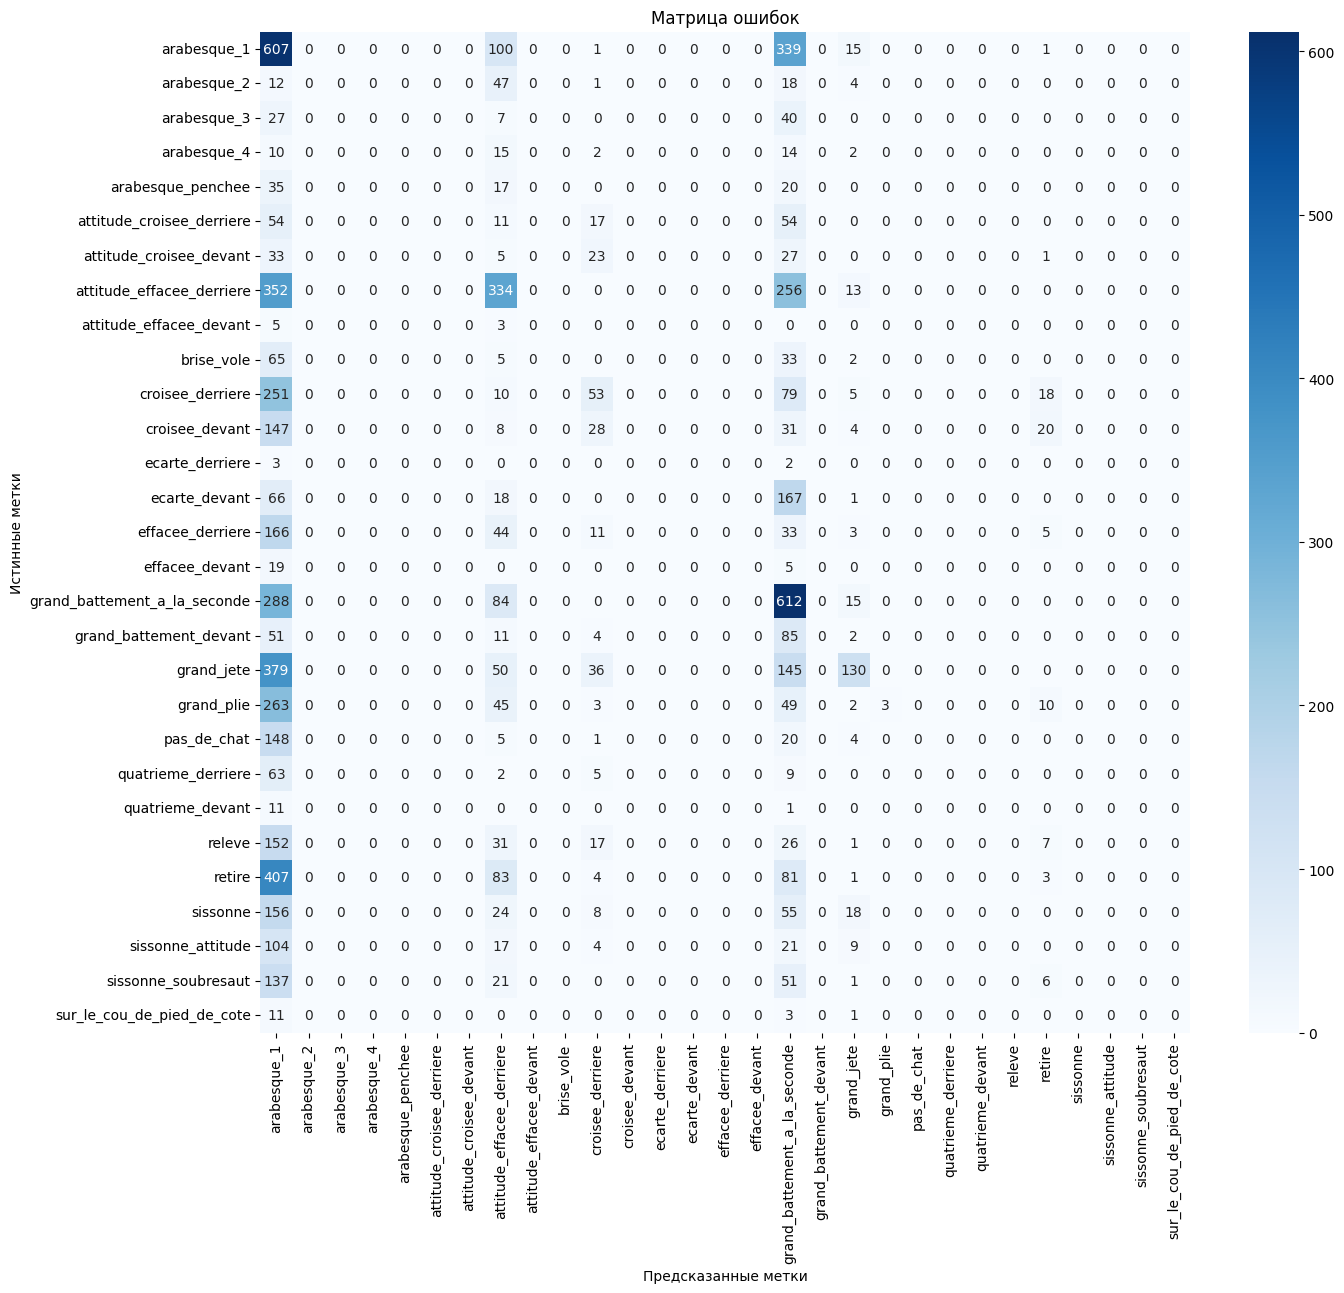

In [ ]:
# Матрица ошибок
conf_matrix_SVC = confusion_matrix(y_test_SVC, y_pred_SVC)

# Визуализация матрицы ошибок
plt.figure(figsize=(15, 13))
sns.heatmap(conf_matrix_SVC, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.class_to_idx.keys(), yticklabels=dataset.class_to_idx.keys())
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок')
plt.show()

### Пробуем обучить RandomForestClassifier

In [ ]:
X_train_RandFor, X_test_RandFor, y_train_RandFor, y_test_RandFor = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Инициализация и обучение модели
clf_RandFor = RandomForestClassifier(random_state=42)
clf_RandFor.fit(X_train_RandFor, y_train_RandFor)

RandomForestClassifier(random_state=42)

In [ ]:
# Предсказание на тестовой выборке
y_pred_RandFor = clf_RandFor.predict(X_test_RandFor)

In [ ]:
# Оценка точности
accuracy_RandFor = accuracy_score(y_test_RandFor, y_pred_RandFor)
print(f"Точность на тестовой выборке: {accuracy_RandFor:.2f}")

Точность на тестовой выборке: 0.97


In [ ]:
# Подробный отчет о классификации
print("Отчет о классификации:")
print(classification_report(y_test_RandFor, y_pred_RandFor))

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1063
           1       1.00      0.89      0.94        82
           2       0.99      0.91      0.94        74
           3       1.00      0.98      0.99        43
           4       1.00      0.92      0.96        72
           5       0.99      0.94      0.97       136
           6       1.00      0.97      0.98        89
           7       0.94      0.98      0.96       955
           8       1.00      0.88      0.93         8
           9       1.00      0.95      0.98       105
          10       0.97      0.96      0.97       416
          11       0.99      0.96      0.97       238
          12       1.00      1.00      1.00         5
          13       1.00      0.95      0.97       252
          14       0.99      0.92      0.96       262
          15       1.00      0.92      0.96        24
          16       0.94      0.99      0.96       999
    

In [ ]:
# Матрица ошибок
conf_matrix_RandFor = confusion_matrix(y_test_RandFor, y_pred_RandFor)
print("Матрица ошибок:")
print(conf_matrix_RandFor)

Матрица ошибок:
[[1046    0    0    0    0    0    0    4    0    0    0    0    0    0
     1    0    8    0    4    0    0    0    0    0    0    0    0    0
     0]
 [   3   73    0    0    0    0    0    5    0    0    0    0    0    0
     0    0    1    0    0    0    0    0    0    0    0    0    0    0
     0]
 [   5    0   67    0    0    0    0    2    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0]
 [   0    0    0   42    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    1    0    0    0    0    0    0    0    0    0
     0]
 [   3    0    0    0   66    0    0    2    0    0    0    0    0    0
     0    0    0    0    1    0    0    0    0    0    0    0    0    0
     0]
 [   1    0    1    0    0  128    0    2    0    0    2    0    0    0
     0    0    1    0    0    0    0    0    0    0    1    0    0    0
     0]
 [   0    0    0    0    0    0   86    0    0    0    0    0    0    0


In [ ]:
# Точность модели на тестовых данных
accuracy_RandFor_test = accuracy_score(y_test_RandFor, y_pred_RandFor)
print(f"Точность на тестовой выборке: {accuracy_RandFor_test:.2f}")

Точность на тестовой выборке: 0.97


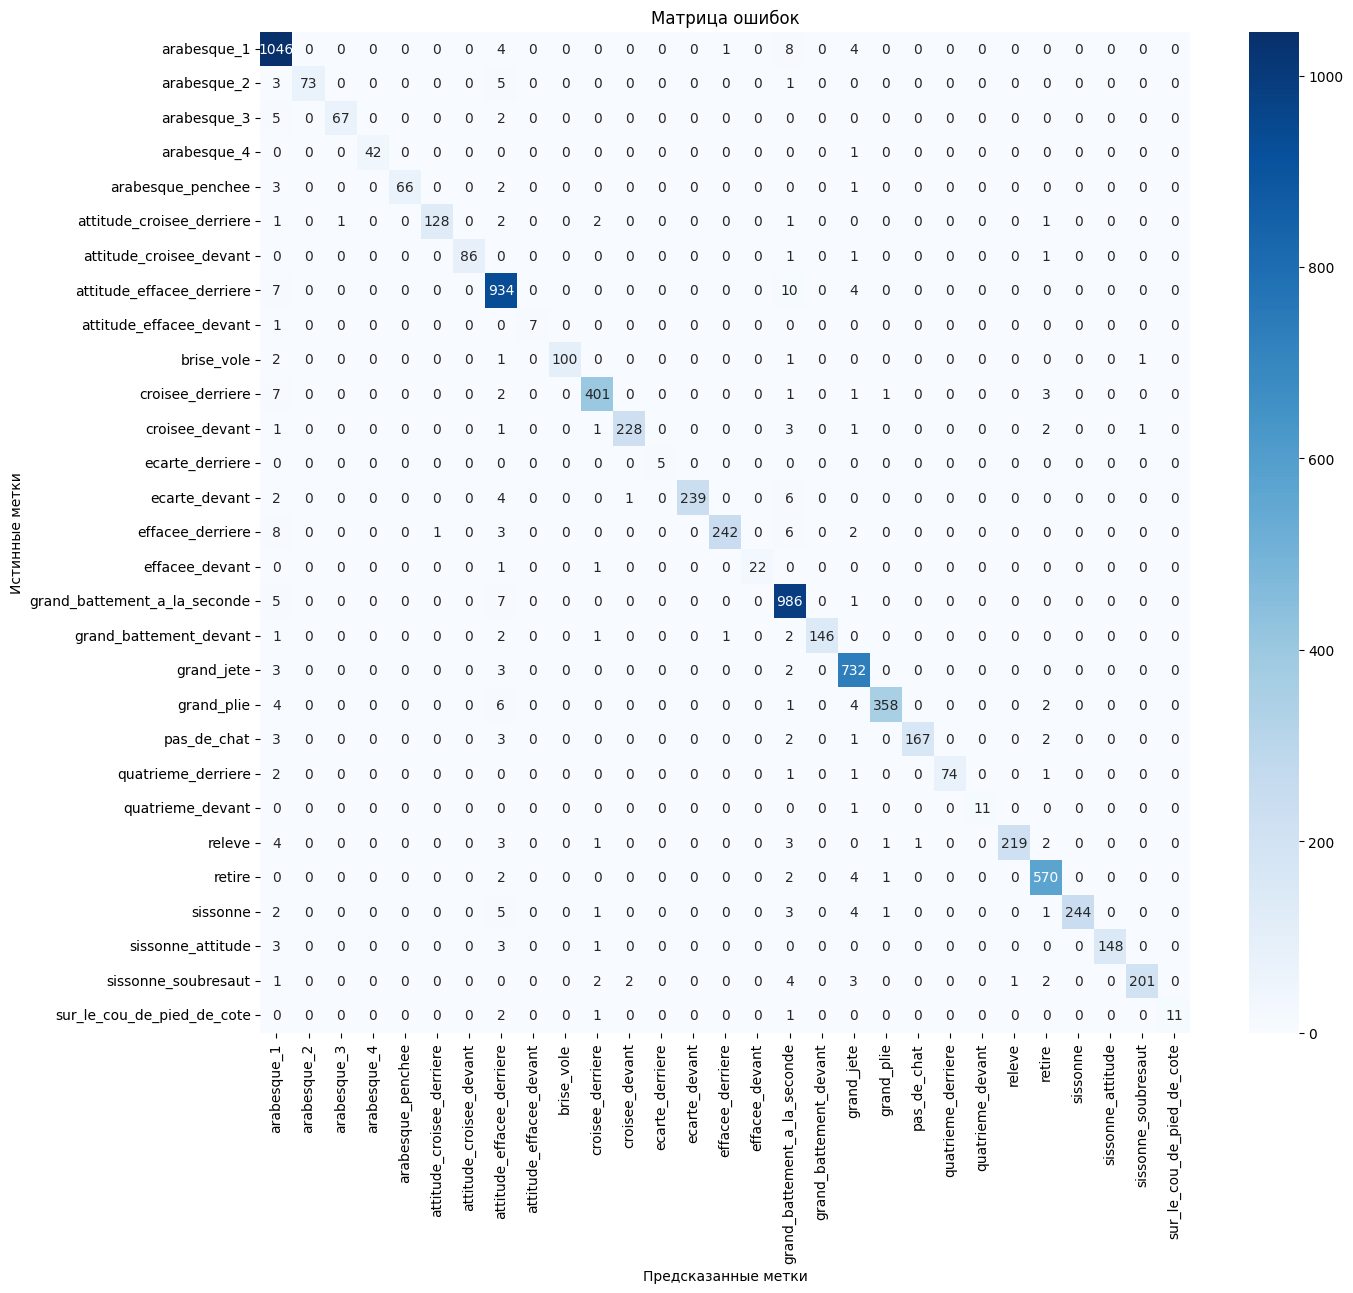

In [ ]:
# Матрица ошибок
conf_matrix_RandFor = confusion_matrix(y_test_RandFor, y_pred_RandFor)

# Визуализация матрицы ошибок
plt.figure(figsize=(15, 13))
sns.heatmap(conf_matrix_RandFor, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.class_to_idx.keys(), yticklabels=dataset.class_to_idx.keys())
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок')
plt.show()

### Попробуем обучить AdaBoostClassifier

In [ ]:
X_train_AdaBo, X_test_AdaBo, y_train_AdaBo, y_test_AdaBo = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

# Инициализация и обучение модели
clf_AdaBo = AdaBoostClassifier(random_state=42)
clf_AdaBo.fit(X_train_AdaBo, y_train_AdaBo)

AdaBoostClassifier(random_state=42)

In [ ]:
# Предсказание на тестовой выборке
y_pred_AdaBo = clf_AdaBo.predict(X_test_AdaBo)

In [ ]:
# Оценка точности
accuracy_AdaBo = accuracy_score(y_test_AdaBo, y_pred_AdaBo)
print(f"Точность на тестовой выборке: {accuracy_AdaBo:.2f}")

Точность на тестовой выборке: 0.21


In [ ]:
# Подробный отчет о классификации
print("Отчет о классификации:")
print(classification_report(y_test_AdaBo, y_pred_AdaBo))

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.17      0.14      0.15      1063
           1       0.00      0.00      0.00        82
           2       0.00      0.00      0.00        74
           3       0.00      0.00      0.00        43
           4       0.00      0.00      0.00        72
           5       0.00      0.00      0.00       136
           6       0.00      0.00      0.00        89
           7       0.40      0.43      0.42       955
           8       0.00      0.00      0.00         8
           9       0.00      0.00      0.00       105
          10       0.11      0.06      0.07       416
          11       0.00      0.00      0.00       238
          12       0.00      0.00      0.00         5
          13       0.00      0.00      0.00       252
          14       0.00      0.00      0.00       262
          15       0.00      0.00      0.00        24
          16       0.18      0.63      0.28       999
    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Матрица ошибок
conf_matrix_AdaBo = confusion_matrix(y_test_AdaBo, y_pred_AdaBo)
print("Матрица ошибок:")
print(conf_matrix_AdaBo)

Матрица ошибок:
[[145   0   0   0   0   0   0 108   0   0  14   0   0   0   0   0 347   0
  373  45   0   0   0   0  30   1   0   0   0]
 [  7   0   0   0   0   0   0  34   0   0   0   0   0   0   0   0  21   0
   18   2   0   0   0   0   0   0   0   0   0]
 [  9   0   0   0   0   0   0   2   0   0   3   0   0   0   0   0  48   0
   11   1   0   0   0   0   0   0   0   0   0]
 [  6   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0  27   0
    7   1   0   0   0   1   0   0   0   0   0]
 [  5   0   0   0   0   0   0   6   0   0   2   0   0   0   0   0  49   0
   10   0   0   0   0   0   0   0   0   0   0]
 [ 28   0   0   0   0   0   0   7   0   0   4   0   0   0   0   0  83   0
    8   1   0   0   0   0   5   0   0   0   0]
 [  3   0   0   0   0   0   0   0   0   0   5   0   0   0   0   0  78   0
    1   0   0   0   0   0   2   0   0   0   0]
 [ 62   0   0   0   0   0   0 413   0   0  24   0   0   3   0   0 167   0
  202  83   0   0   0   0   1   0   0   0   0]
 [  0   0   0   

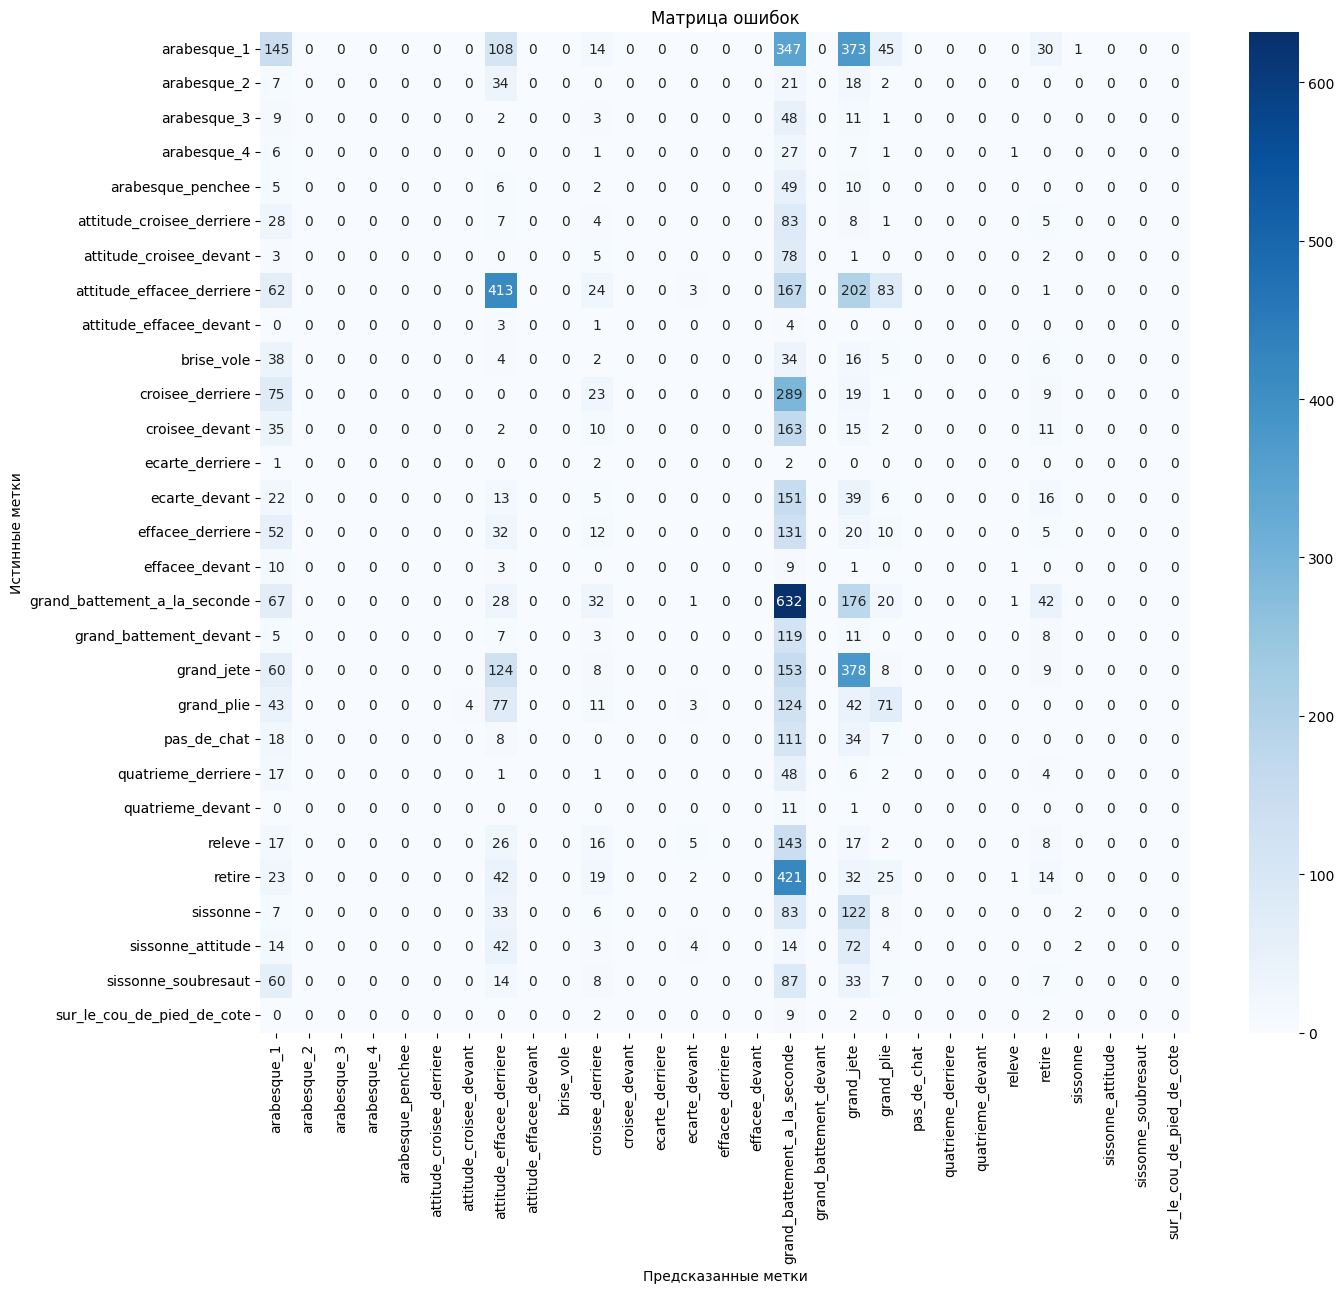

In [ ]:
# Матрица ошибок
conf_matrix_AdaBo = confusion_matrix(y_test_AdaBo, y_pred_AdaBo)

# Визуализация матрицы ошибок
plt.figure(figsize=(15, 13))
sns.heatmap(conf_matrix_AdaBo, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.class_to_idx.keys(), yticklabels=dataset.class_to_idx.keys())
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок')
plt.show()

### Попробуем обучить KNeighborsClassifier

In [ ]:
X_train_KN, X_test_KN, y_train_KN, y_test_KN = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Инициализация и обучение модели
clf_KN = KNeighborsClassifier()
clf_KN.fit(X_train_KN, y_train_KN)

KNeighborsClassifier()

In [ ]:
# Предсказание на тестовой выборке
y_pred_KN = clf_KN.predict(X_test_KN)

In [ ]:
# Оценка точности
accuracy_KN = accuracy_score(y_test_KN, y_pred_KN)
print(f"Точность на тестовой выборке: {accuracy_KN:.2f}")

Точность на тестовой выборке: 0.78


In [ ]:
# Подробный отчет о классификации
print("Отчет о классификации:")
print(classification_report(y_test_KN, y_pred_KN))

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.60      0.84      0.70      1063
           1       0.66      0.72      0.69        82
           2       0.69      0.74      0.71        74
           3       0.58      0.79      0.67        43
           4       0.60      0.74      0.66        72
           5       0.67      0.74      0.70       136
           6       0.71      0.84      0.77        89
           7       0.75      0.79      0.77       955
           8       1.00      0.88      0.93         8
           9       0.72      0.69      0.70       105
          10       0.82      0.80      0.81       416
          11       0.89      0.75      0.81       238
          12       1.00      0.80      0.89         5
          13       0.81      0.79      0.80       252
          14       0.88      0.77      0.82       262
          15       1.00      0.75      0.86        24
          16       0.81      0.77      0.79       999
    

In [ ]:
# Матрица ошибок
conf_matrix_KN = confusion_matrix(y_test_KN, y_pred_KN)
print("Матрица ошибок:")
print(conf_matrix_KN)

Матрица ошибок:
[[890   9   2   2   9   9   5  48   0   5  12   0   0   6   4   0  27   0
   20   1   0   0   0   2   8   3   0   1   0]
 [  6  59   0   0   0   1   1   4   0   0   0   1   0   0   0   0   4   0
    1   0   0   0   0   0   2   2   0   1   0]
 [  8   0  55   0   0   0   0   4   0   1   1   3   0   0   1   0   1   0
    0   0   0   0   0   0   0   0   0   0   0]
 [  1   0   1  34   1   1   0   0   0   0   1   1   0   0   0   0   0   0
    1   2   0   0   0   0   0   0   0   0   0]
 [  5   0   0   0  53   2   0   0   0   1   1   2   0   2   0   0   2   0
    1   1   0   0   0   0   1   1   0   0   0]
 [ 12   1   0   1   1 101   2   1   0   0   0   0   0   3   1   0   5   0
    5   0   0   0   0   0   2   1   0   0   0]
 [  7   1   0   0   0   1  75   1   0   0   2   0   0   0   0   0   2   0
    0   0   0   0   0   0   0   0   0   0   0]
 [ 92   2   3   2   6   9   4 752   0   2   7   3   0   7   2   0  24   2
   20   1   1   0   0   2   7   2   4   1   0]
 [  1   0   0   

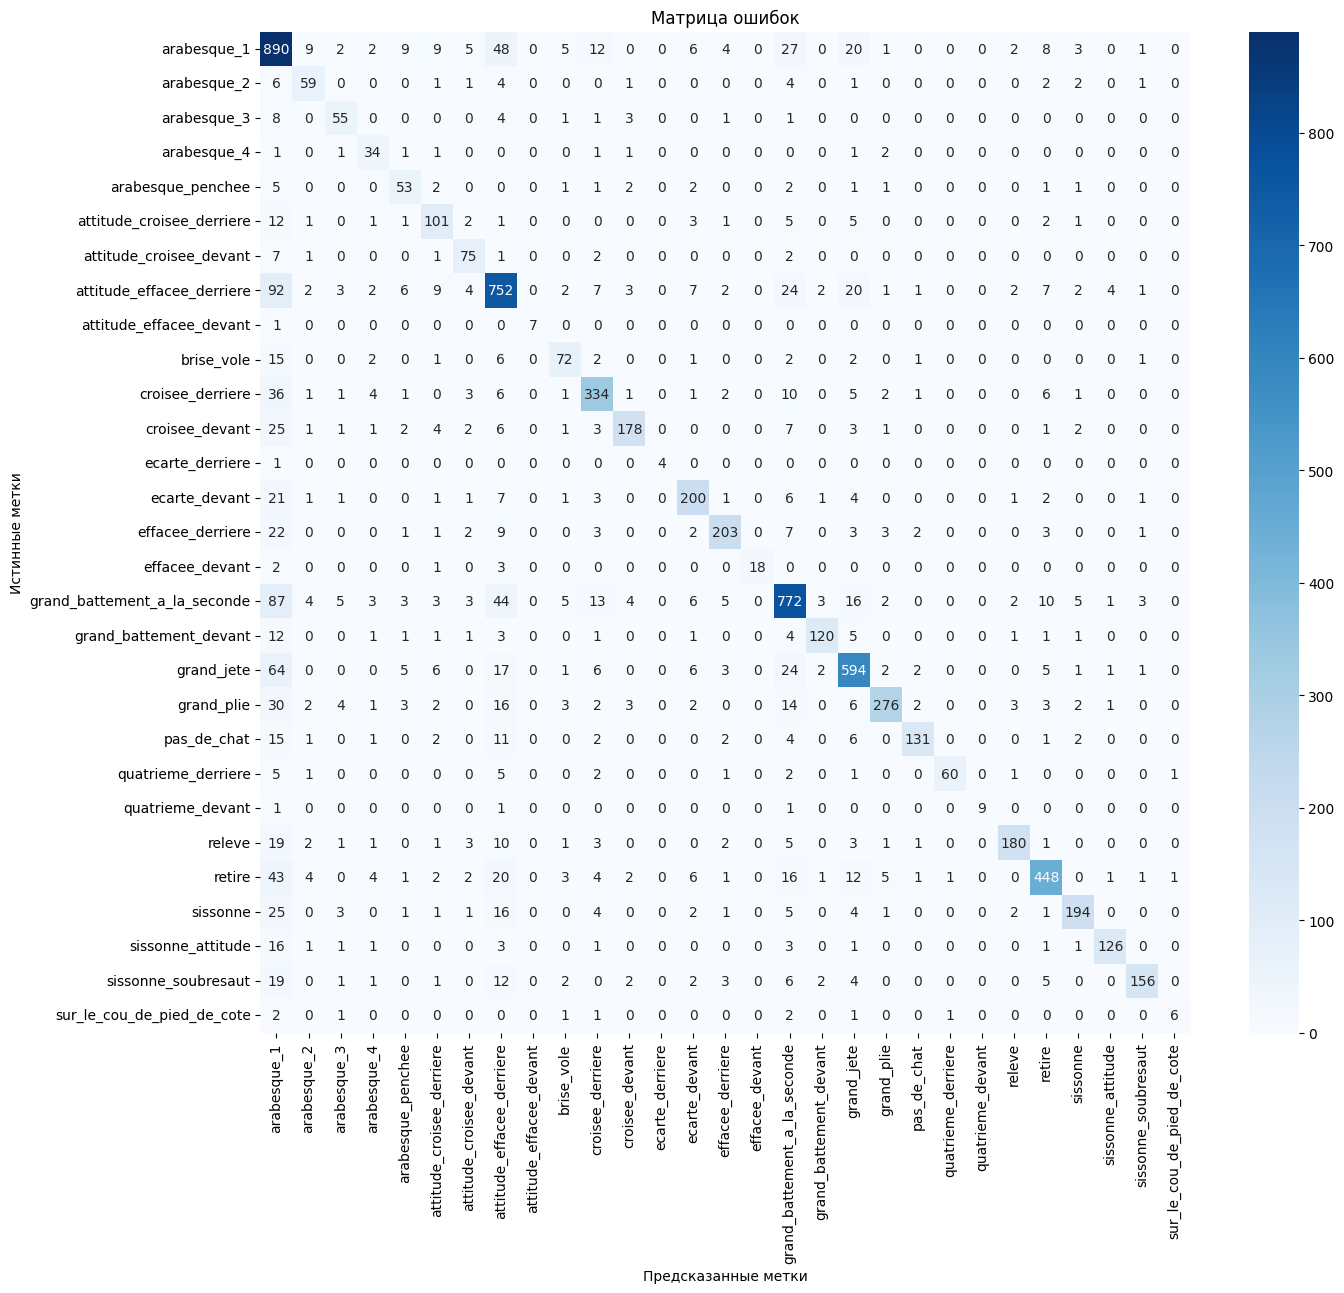

In [ ]:
# Матрица ошибок
conf_matrix_KN = confusion_matrix(y_test_KN, y_pred_KN)

# Визуализация матрицы ошибок
plt.figure(figsize=(15, 13))
sns.heatmap(conf_matrix_KN, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.class_to_idx.keys(), yticklabels=dataset.class_to_idx.keys())
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок')
plt.show()

### Попробуем обучить GaussianNB

In [ ]:
X_train_GNB, X_test_GNB, y_train_GNB, y_test_GNB = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Инициализация и обучение модели
clf_GNB = GaussianNB()
clf_GNB.fit(X_train_GNB, y_train_GNB)

GaussianNB()

In [ ]:
# Предсказание на тестовой выборке
y_pred_GNB = clf_GNB.predict(X_test_GNB)

In [ ]:
# Оценка точности
accuracy_GNB = accuracy_score(y_test_GNB, y_pred_GNB)
print(f"Точность на тестовой выборке: {accuracy_GNB:.2f}")

Точность на тестовой выборке: 0.12


### Попробуем обучить GradientBoostingClassifier

In [ ]:
X_train_GBoo, X_test_GBoo, y_train_GBoo, y_test_GBoo = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Инициализация и обучение модели
# clf_GBoo = GradientBoostingClassifier()
clf_GBoo = GradientBoostingClassifier(n_estimators=100,
                                      learning_rate=1.0,
                                      max_depth=1,
                                      random_state=0)

clf_GBoo.fit(X_train_GBoo, y_train_GBoo)

GradientBoostingClassifier(learning_rate=1.0, max_depth=1, random_state=0)

In [ ]:
# Предсказание на тестовой выборке
y_pred_GBoo = clf_GBoo.predict(X_test_GBoo)

In [ ]:
# Оценка точности
accuracy_GBoo = accuracy_score(y_test_GBoo, y_pred_GBoo)
print(f"Точность на тестовой выборке: {accuracy_GBoo:.2f}")

Точность на тестовой выборке: 0.43


Оно училось 10 минут -- и такой результат...

### Попробуем обучить ExtraTreesClassifier

In [ ]:
X_train_ExTree, X_test_ExTree, y_train_ExTree, y_test_ExTree = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.datasets import make_classification

X_train_ExTree, y_train_ExTree = make_classification(n_features=51,
                                                     random_state=42)
clf_ExTree = ExtraTreesClassifier(n_estimators=100,
                                  random_state=0)
clf_ExTree.fit(X_train_ExTree, y_train_ExTree)

ExtraTreesClassifier(random_state=0)

In [ ]:
# Предсказание на тестовой выборке
y_pred_ExTree = clf_ExTree.predict(X_test_ExTree)

In [ ]:
# Оценка точности
accuracy_ExTree = accuracy_score(y_test_ExTree, y_pred_ExTree)
print(f"Точность на тестовой выборке: {accuracy_ExTree:.2f}")

Точность на тестовой выборке: 0.03
